In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"
import numpy as np
import librosa
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import layers, models
from tensorflow.keras.regularizers import l2

In [2]:
DATASET_PATH = "../data/GTZAN"
SAMPLE_RATE = 22050
DURATION = 30
N_MELS = 128
HOP_LENGTH = 512
MAX_LEN = 130  # time frames

NUM_CLASSES = 10

In [3]:
def extract_mel(file_path):
    try:
        y, sr = librosa.load(file_path, sr=SAMPLE_RATE, duration=DURATION)

        mel = librosa.feature.melspectrogram(
            y=y,
            sr=sr,
            n_mels=N_MELS,
            hop_length=HOP_LENGTH
        )

        mel_db = librosa.power_to_db(mel, ref=np.max)

        # Normalize
        mel_db = (mel_db - np.mean(mel_db)) / (np.std(mel_db) + 1e-9)

        # Fix length
        if mel_db.shape[1] < MAX_LEN:
            mel_db = np.pad(mel_db, ((0,0),(0, MAX_LEN - mel_db.shape[1])))
        else:
            mel_db = mel_db[:, :MAX_LEN]

        return mel_db

    except:
        return None

In [4]:
X = []
y = []

genres = os.listdir(DATASET_PATH)

for genre in genres:
    genre_path = os.path.join(DATASET_PATH, genre)
    
    for file in os.listdir(genre_path):
        if file.endswith(".wav"):
            file_path = os.path.join(genre_path, file)
            mel = extract_mel(file_path)
            
            if mel is not None:
                X.append(mel)
                y.append(genre)

print("Loaded:", len(X))

C:\Users\adith\AppData\Local\Temp\ipykernel_22072\1252301840.py:3: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(file_path, sr=SAMPLE_RATE, duration=DURATION)
C:\Users\adith\anaconda3\envs\musiccnn\lib\site-packages\librosa\core\audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


Loaded: 999


In [5]:
X = np.array(X)
X = X[..., np.newaxis]  # add channel

le = LabelEncoder()
y_encoded = le.fit_transform(y)
y_categorical = to_categorical(y_encoded)

print("X shape:", X.shape)
print("y shape:", y_categorical.shape)

X shape: (999, 128, 130, 1)
y shape: (999, 10)


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_categorical,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

In [7]:
model = models.Sequential([

    layers.Conv2D(32, (3,3), activation='relu',
                  kernel_regularizer=l2(0.0001),
                  input_shape=X_train.shape[1:]),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu',
                  kernel_regularizer=l2(0.0001)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu',
                  kernel_regularizer=l2(0.0001)),
    layers.BatchNormalization(),

    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),

    layers.Dense(NUM_CLASSES, activation='softmax')
])

In [8]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [9]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=40,
    batch_size=16
)

Epoch 1/40
50/50 [==============================] - 7s 124ms/step - loss: 1.9354 - accuracy: 0.2941 - val_loss: 2.3765 - val_accuracy: 0.1000
Epoch 2/40
50/50 [==============================] - 6s 114ms/step - loss: 1.6593 - accuracy: 0.4080 - val_loss: 2.7509 - val_accuracy: 0.1000
Epoch 3/40
50/50 [==============================] - 6s 115ms/step - loss: 1.5036 - accuracy: 0.4681 - val_loss: 4.6038 - val_accuracy: 0.1000
Epoch 4/40
50/50 [==============================] - 6s 116ms/step - loss: 1.4418 - accuracy: 0.4856 - val_loss: 5.7332 - val_accuracy: 0.1000
Epoch 5/40
50/50 [==============================] - 6s 116ms/step - loss: 1.3314 - accuracy: 0.5344 - val_loss: 6.4336 - val_accuracy: 0.1000
Epoch 6/40
50/50 [==============================] - 6s 119ms/step - loss: 1.2583 - accuracy: 0.5494 - val_loss: 7.2630 - val_accuracy: 0.1000
Epoch 7/40
50/50 [==============================] - 6s 125ms/step - loss: 1.1884 - accuracy: 0.5832 - val_loss: 6.1419 - val_accuracy: 0.1000
Epoch 

In [10]:
model.save("../models/genre_mel_cnn.keras")

In [11]:
import pickle

with open("../models/genre_label_encoder.pkl", "wb") as f:
    pickle.dump(le, f)

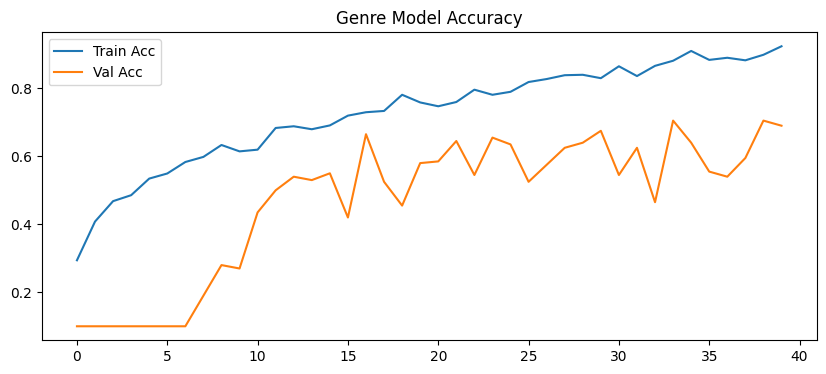

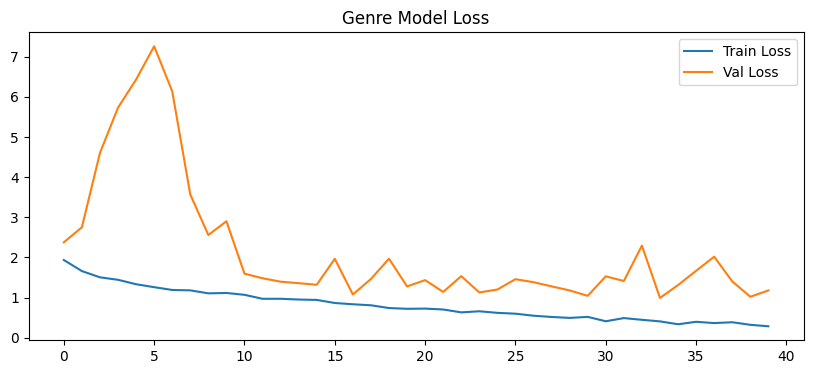

In [12]:
plt.figure(figsize=(10,4))
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend()
plt.title("Genre Model Accuracy")
plt.show()

plt.figure(figsize=(10,4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Genre Model Loss")
plt.show()